# Source D — Key Findings: BTS FAF5 County Freight Flows

This notebook shows the most important, already-verified results from
`analysis-output/source-d/source-d-findings.md`. It loads existing computed
artifacts (`source_d_stats.json`, saved figures, hub/crossvalidation CSVs)
rather than re-running the full ingestion or analysis pipeline.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "figures"

with open(REPO_ROOT / "analysis-output" / "source_d_stats.json") as f:
    stats = json.load(f)
stats

{'total_counties': 3144,
 'top_hub_county': 'Harris County, Texas',
 'top_hub_tons': 731121.1480472,
 'log_tons_vs_hhi_corr': 0.2783665288230553,
 'log_tons_vs_unemployment_velocity_corr': 0.049778960960116685,
 'log_tons_vs_gdp_velocity_pct_corr': 0.07653846121500077,
 'hhi_vs_unemployment_velocity_corr': -0.026106799593700016,
 'hhi_vs_gdp_velocity_pct_corr': 0.06880769610503741,
 'gdp_velocity_pct_by_tons_quartile': {'1': 0.01613101600270855,
  '2': 0.016337685983913025,
  '3': 0.02071231436657182,
  '4': 0.024044924738748724}}

## 1. Dataset

3,144 US counties/county-equivalents, each with 2022 freight tonnage from
BTS's FAF5 Experimental County-Level Estimates: outbound/inbound tonnage
totals, a 5-way commodity-group (`sctgG5`) breakdown per direction, and a
pooled county+FAF-zone partner concentration index (HHI) per direction.
A single static 2022 cross-section, not a time series. Zero nulls, zero
duplicate FIPS codes, full crosswalk coverage.

In [2]:
source_d_df = pd.read_parquet(REPO_ROOT / "data" / "source_d_faf.parquet")
print(f"{len(source_d_df):,} counties")
source_d_df[["county_name", "fips_code", "total_outbound_tons", "total_inbound_tons", "out_partner_hhi", "in_partner_hhi"]].head()

3,144 counties


,county_name,fips_code,total_outbound_tons,total_inbound_tons,out_partner_hhi,in_partner_hhi
0,"Autauga County, Alabama",01001,2132.708707,3989.310310,0.017767,0.020623
1,"Baldwin County, Alabama",01003,7142.368661,12752.046050,0.149774,0.101170
2,"Barbour County, Alabama",01005,1588.375946,1349.542598,0.015944,0.020719
3,"Bibb County, Alabama",01007,1246.223770,2801.294216,0.055737,0.043456
4,"Blount County, Alabama",01009,1491.392670,3520.044184,0.068469,0.071197


## 2. Finding: Scalar Tonnage Separates Hubs From Sinks by Orders of Magnitude

Harris County, TX (Houston) leads the nation at 731K tons, ahead of LA
County (540K) and Cook County/Chicago (348K). At the other extreme, rural
counties fall to a few hundred tons or less. Loving County, TX
(population ~64) is a striking exception: 9,842 outbound tons against just
59 inbound -- not noise, but a genuine Permian Basin oil/gas export point
the data correctly captures despite the county's near-zero population.

Top hub: Harris County, Texas (731,121 tons)


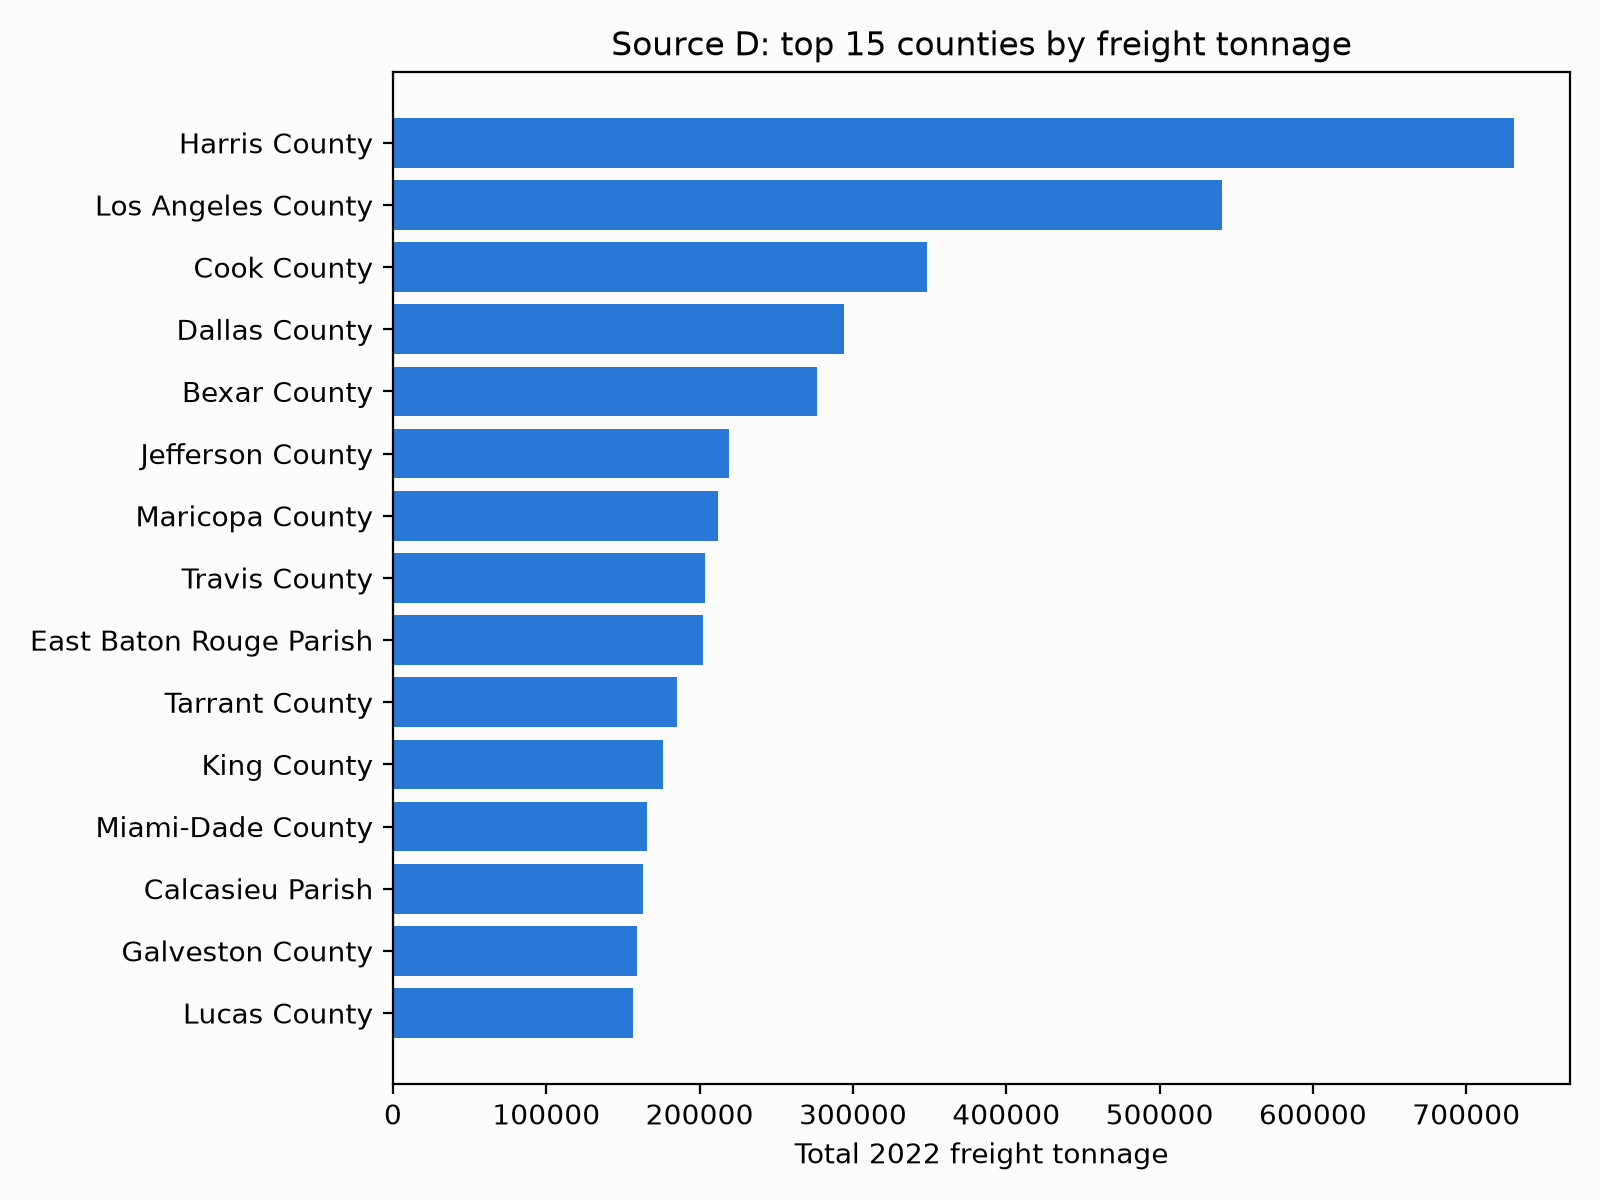

In [3]:
print("Top hub:", stats["top_hub_county"], f"({stats['top_hub_tons']:,.0f} tons)")
display(Image(filename=str(FIGURES_DIR / "source-d-figure-01-top-hubs.png")))

In [4]:
hubs = pd.read_csv(REPO_ROOT / "outputs" / "source_d_hubs.csv")
hubs.head(10)

,county_name,fips_code,total_tons,mean_partner_hhi
0,"Harris County, Texas",48201,731121.148047,0.180765
1,"Los Angeles County, California",6037,540493.219006,0.210468
2,"Cook County, Illinois",17031,348042.420229,0.109432
3,"Dallas County, Texas",48113,294117.937437,0.115365
4,"Bexar County, Texas",48029,276851.942832,0.312384
5,"Jefferson County, Texas",48245,219125.394266,0.129522
6,"Maricopa County, Arizona",4013,212019.846714,0.388793
7,"Travis County, Texas",48453,203278.666397,0.302699
8,"East Baton Rouge Parish, Louisiana",22033,202149.707468,0.053845
9,"Tarrant County, Texas",48439,185177.848135,0.120082


## 3. Finding: Partner Concentration (HHI) Reverses Direction at National Scale

`docs/plans/ingestion_recon.md` (Source D) two-state regional design spike (Rhode Island, New
Jersey) found hub counties *less* concentrated than rural ones. At full
national scale the direction flips: log10(tons) vs. mean partner HHI
correlates positively (r = 0.278) -- big hubs funnel large volume through
a few dominant interstate corridors, while small counties spread modest
volume evenly across nearby neighbors. This is a real, mechanistically
understood scale-dependent reversal, not noise.

log10(tons) vs. mean_partner_hhi r = 0.2783665288230553


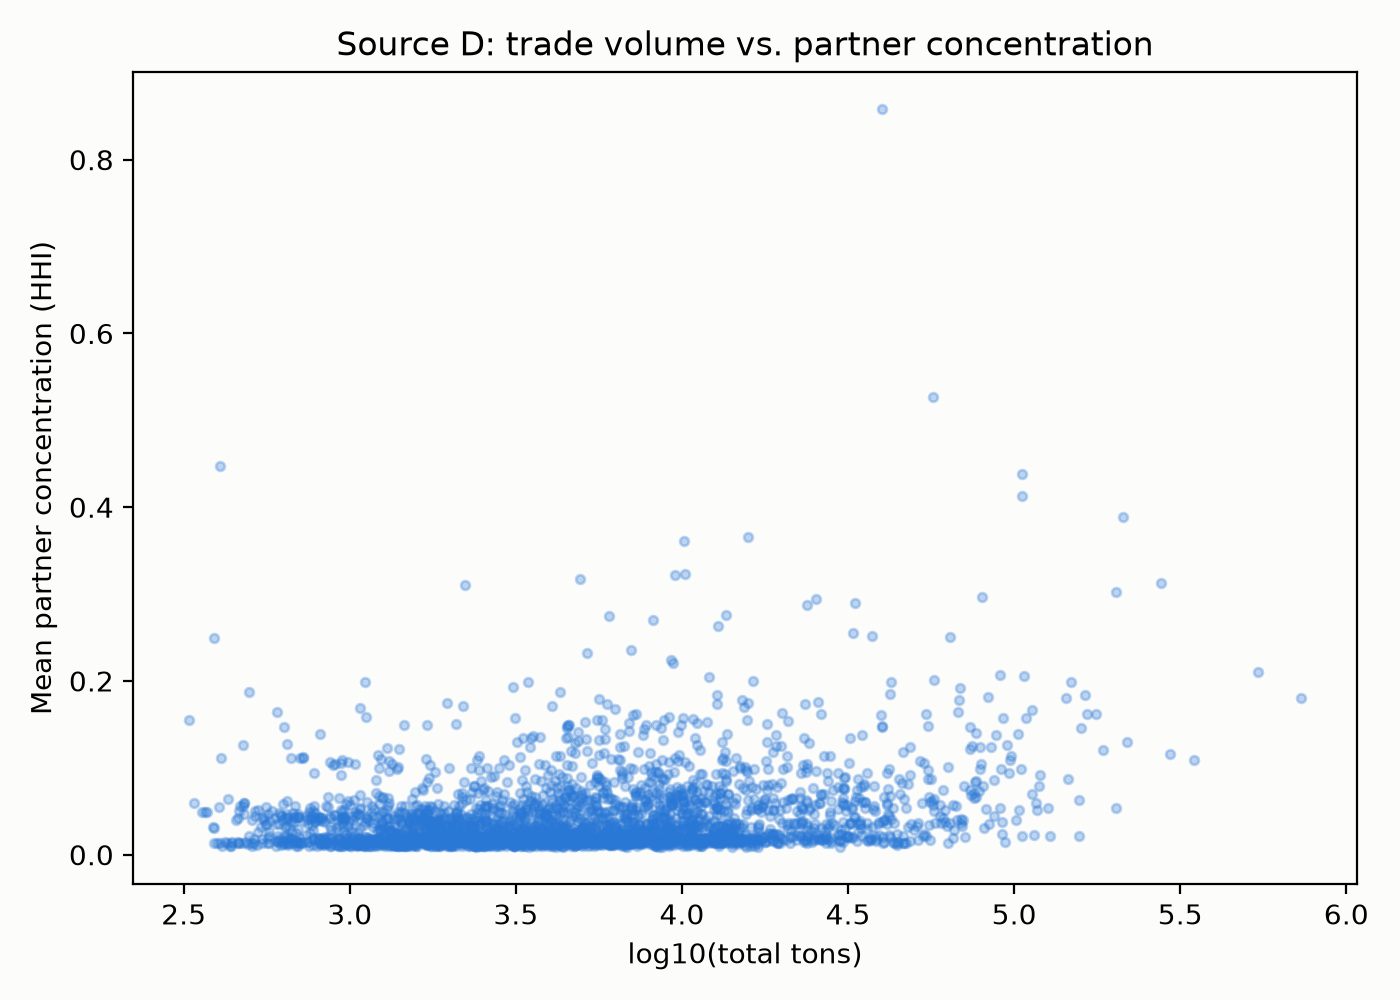

In [5]:
print("log10(tons) vs. mean_partner_hhi r =", stats["log_tons_vs_hhi_corr"])
display(Image(filename=str(FIGURES_DIR / "source-d-figure-02-tons-vs-concentration.png")))

In [6]:
for fips, name in [("48201", "Harris County, TX"), ("06037", "LA County, CA"), ("17031", "Cook County, IL"),
                    ("30069", "Petroleum County, MT"), ("48301", "Loving County, TX")]:
    row = source_d_df[source_d_df["fips_code"] == fips].iloc[0]
    print(f"{name:24s} out_hhi={row['out_partner_hhi']:.3f} in_hhi={row['in_partner_hhi']:.3f}")

Harris County, TX        out_hhi=0.201 in_hhi=0.161
LA County, CA            out_hhi=0.231 in_hhi=0.189
Cook County, IL          out_hhi=0.108 in_hhi=0.111
Petroleum County, MT     out_hhi=0.040 in_hhi=0.023
Loving County, TX        out_hhi=0.024 in_hhi=0.012


## 4. Finding: Trade Volume Weakly but Monotonically Tracks GDP Momentum

Cross-validating against Source C's size-normalized GDP velocity, mean
velocity rises cleanly across freight-tonnage quartiles (1.6% -> 1.6% ->
2.1% -> 2.4%/year) -- weak in absolute correlation terms (r = 0.077) but
monotonic, unlike Source F's near-zero, directionless result against the
same velocity measure.

log(tons) vs. gdp_velocity_pct r = 0.07653846121500077
gdp_velocity_pct by tons quartile: {'1': 0.01613101600270855, '2': 0.016337685983913025, '3': 0.02071231436657182, '4': 0.024044924738748724}


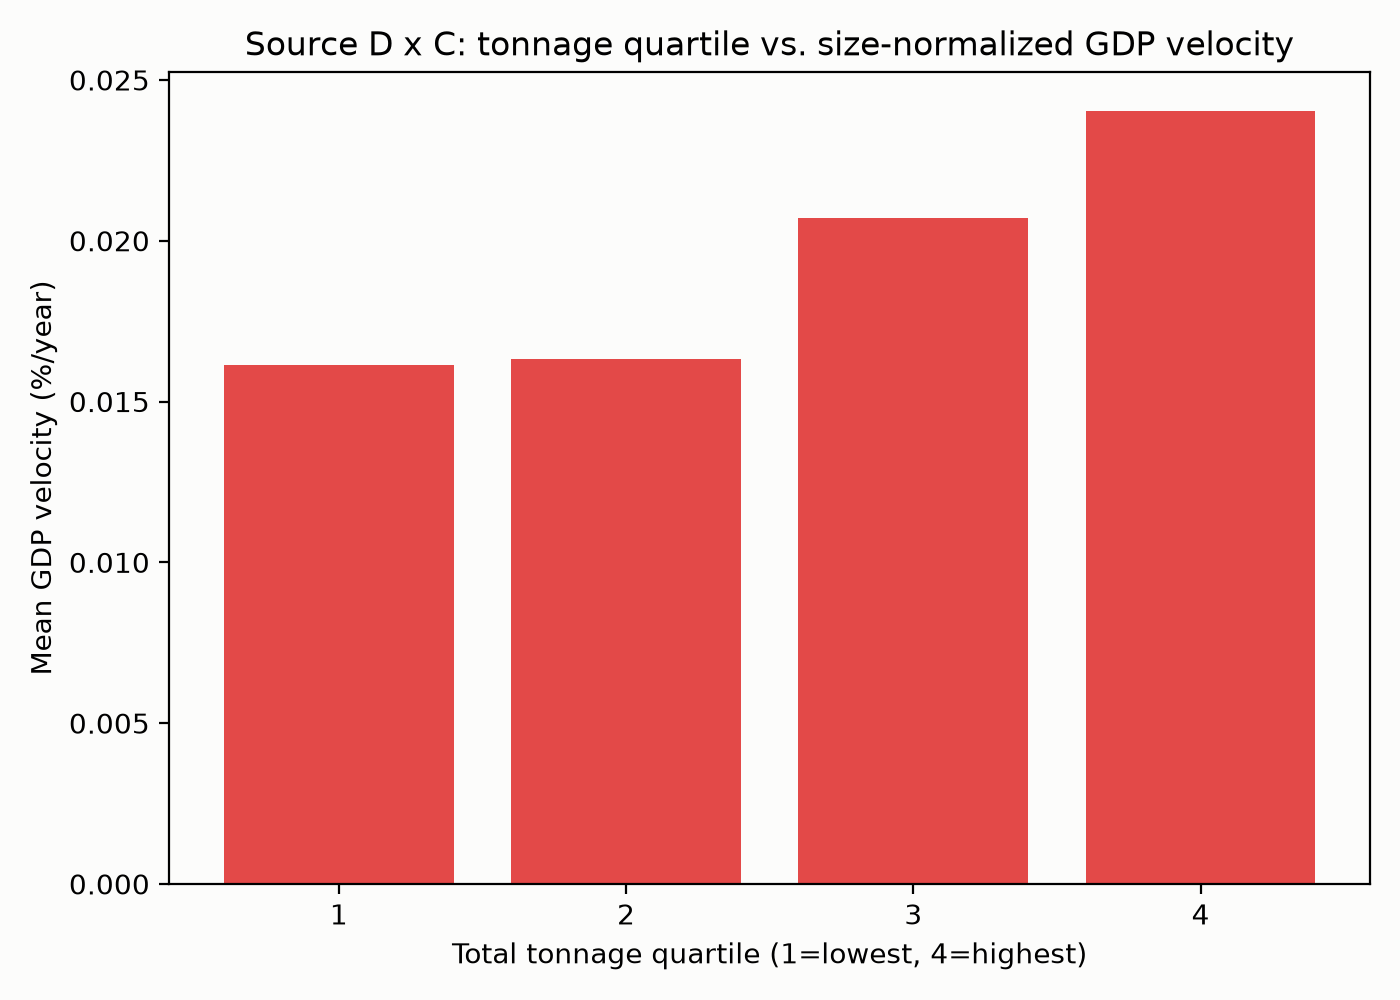

In [7]:
print("log(tons) vs. gdp_velocity_pct r =", stats["log_tons_vs_gdp_velocity_pct_corr"])
print("gdp_velocity_pct by tons quartile:", stats["gdp_velocity_pct_by_tons_quartile"])
display(Image(filename=str(FIGURES_DIR / "source-d-figure-03-tons-vs-velocity.png")))

## 5. Limitation: No Dollar-Value Column

Both `macro_pre_scoping_spec.pdf` and `E_macro_extendedProposal.pdf`
describe Source D as tracking "freight tonnage and dollar value." The
experimental county-level product ships tonnage only -- the base
(non-experimental) FAF5 product does carry value fields per the general
user guide, but the county-level disaggregation drops them. This is a
confirmed scope reduction, not a parsing gap.

In [8]:
[c for c in source_d_df.columns if "value" in c.lower()]  # empty: no dollar-value column in this product

[]

## 6. Proposal Alignment Summary

See `analysis-output/source-d/source-d-findings.md` section 8 for the full
assessment. Short version: the core hub-vs-sink framing holds at national
scale, but two deviations from the scoping docs are real and documented --
BTS's own county/FAF-zone hybrid table structure already solves the
"combinatorial matrix explosion" risk (superseding the spec's proposed
top-K-per-origin truncation), and the county-level product is tonnage-only
with no dollar-value column despite both docs describing Source D as
tracking both.